# SEGMENT 4 — Regularized Regression & Gradient Boosting

**Project**: HDB Resale Price Prediction  
**Models**: Ridge · Lasso · Elastic Net · Gradient Boosting Regressor  
**Primary Metrics**: MAE · RMSE · R²  

---

## Why Regularization?

With 77 original columns (expanding to many more after OHE), the model risks:
- **Multicollinearity**: Many amenity features are correlated (e.g., MRT distance vs bus distance)
- **Overfitting**: Too many features relative to signal

Regularization penalizes large coefficients:

| Model | Penalty | Effect |
|-------|---------|--------|
| **Ridge** | L2 = α × Σβ² | Shrinks all coefficients toward zero, none reach exactly 0 |
| **Lasso** | L1 = α × Σ\|β\| | Shrinks some coefficients to exactly 0 (feature selection) |
| **Elastic Net** | α × [ρ × L1 + (1-ρ) × L2] | Hybrid — balances Ridge and Lasso behavior |

Higher α = stronger penalty = more shrinkage = higher bias but lower variance.

---

## Why Gradient Boosting?

Gradient Boosting is an **ensemble of weak trees built sequentially**:
- Each tree corrects the errors of the previous one
- The final prediction = sum of all tree outputs × learning rate
- Naturally handles non-linearities, interactions, and outliers
- Does NOT require scaling (uses Pipeline B)

---
## Step 4.1 — Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score

print('Imports complete.')

def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

Imports complete.


---
## Step 4.2 — Load Preprocessed Data

In [2]:
X_train_A = np.load('artifacts/X_train_A.npy')
X_test_A  = np.load('artifacts/X_test_A.npy')
X_train_B = np.load('artifacts/X_train_B.npy')
X_test_B  = np.load('artifacts/X_test_B.npy')
y_train   = np.load('artifacts/y_train.npy')
y_test    = np.load('artifacts/y_test.npy')
feature_names_A = joblib.load('artifacts/feature_names_A.pkl')
feature_names_B = joblib.load('artifacts/feature_names_B.pkl')
baseline_results = pd.read_csv('artifacts/results_baseline.csv')

print(f'X_train_A (scaled) : {X_train_A.shape}')
print(f'X_train_B (tree)   : {X_train_B.shape}')
print(f'y_train mean       : ${y_train.mean():,.0f}')

X_train_A (scaled) : (120507, 133)
X_train_B (tree)   : (120507, 133)
y_train mean       : $449,417


---
## Step 4.3 — Helper Functions

In [3]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test, cv_splits=5):
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    train_r2  = r2_score(y_train, y_pred_train)
    test_mae  = mean_absolute_error(y_test, y_pred_test)
    test_rmse = root_mean_squared_error(y_test, y_pred_test)
    test_r2   = r2_score(y_test, y_pred_test)

    kf = KFold(n_splits=cv_splits, shuffle=True, random_state=42)
    cv_rmse = -cross_val_score(model, X_train, y_train,
                               scoring='neg_root_mean_squared_error', cv=kf, n_jobs=-1)
    cv_r2   = cross_val_score(model, X_train, y_train,
                              scoring='r2', cv=kf, n_jobs=-1)

    result = {
        'Model'        : name,
        'Train R²'     : round(train_r2, 4),
        'Test MAE'     : round(test_mae, 0),
        'Test RMSE'    : round(test_rmse, 0),
        'Test R²'      : round(test_r2, 4),
        'CV RMSE Mean' : round(cv_rmse.mean(), 0),
        'CV RMSE Std'  : round(cv_rmse.std(), 0),
        'CV R² Mean'   : round(cv_r2.mean(), 4),
        'R² Gap'       : round(train_r2 - test_r2, 4),
    }
    print(f'[{name}]  MAE=${test_mae:,.0f}  RMSE=${test_rmse:,.0f}  R²={test_r2:.4f}  CV_RMSE=${cv_rmse.mean():,.0f}±{cv_rmse.std():,.0f}')
    return result, model, y_pred_test

---
## Step 4.4 — Model 4: Ridge Regression

**Alpha search** to understand shrinkage effect before tuning.  
**Metric to watch**: CV RMSE across alpha values.  
**Default alpha=1.0** run first, then full GridSearch in Segment 5.

In [4]:
ridge_result, ridge_model, ridge_pred = evaluate_model(
    'Ridge (alpha=1.0)',
    Ridge(alpha=1.0),
    X_train_A, X_test_A, y_train, y_test
)

[Ridge (alpha=1.0)]  MAE=$35,637  RMSE=$46,877  R²=0.8922  CV_RMSE=$47,400±387


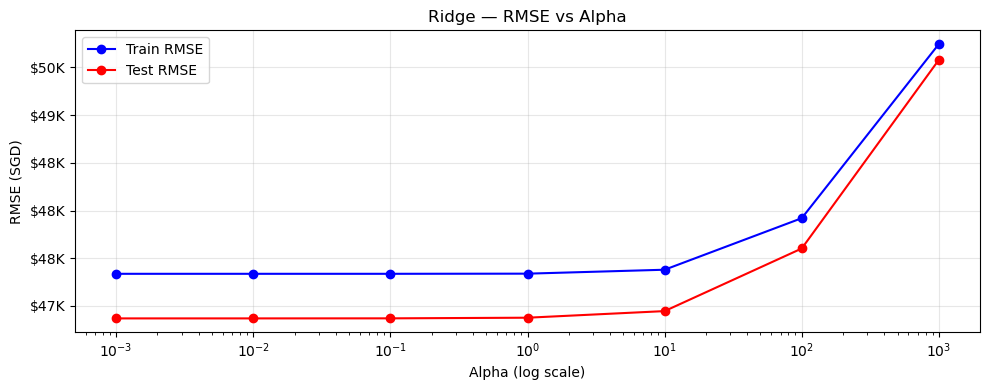

In [5]:
# Ridge alpha path — how does RMSE change with alpha?
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
ridge_train_rmse, ridge_test_rmse, ridge_nonzero = [], [], []

for a in alphas:
    m = Ridge(alpha=a)
    m.fit(X_train_A, y_train)
    ridge_train_rmse.append(root_mean_squared_error(y_train, m.predict(X_train_A)))
    ridge_test_rmse.append(root_mean_squared_error(y_test,   m.predict(X_test_A)))
    ridge_nonzero.append(np.sum(np.abs(m.coef_) > 1e-6))

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogx(alphas, ridge_train_rmse, 'b-o', label='Train RMSE')
ax.semilogx(alphas, ridge_test_rmse,  'r-o', label='Test RMSE')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('RMSE (SGD)')
ax.set_title('Ridge — RMSE vs Alpha', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 4.5 — Model 5: Lasso Regression

Lasso adds sparsity: some coefficients will be driven to **exactly 0**.  
**Secondary metric**: Number of non-zero features (built-in feature selection).  
**Primary metric**: CV RMSE.

In [6]:
lasso_result, lasso_model, lasso_pred = evaluate_model(
    'Lasso (alpha=0.01)',
    Lasso(alpha=0.01, max_iter=10000),
    X_train_A, X_test_A, y_train, y_test
)

/home/auyan/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.163e+13, tolerance: 1.977e+11
  model = cd_fast.enet_coordinate_descent(
/home/auyan/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.208e+13, tolerance: 1.984e+11
  model = cd_fast.enet_coordinate_descent(
/home/auyan/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasi

[Lasso (alpha=0.01)]  MAE=$35,629  RMSE=$46,870  R²=0.8923  CV_RMSE=$47,398±385


/home/auyan/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.163e+13, tolerance: 1.977e+11
  model = cd_fast.enet_coordinate_descent(


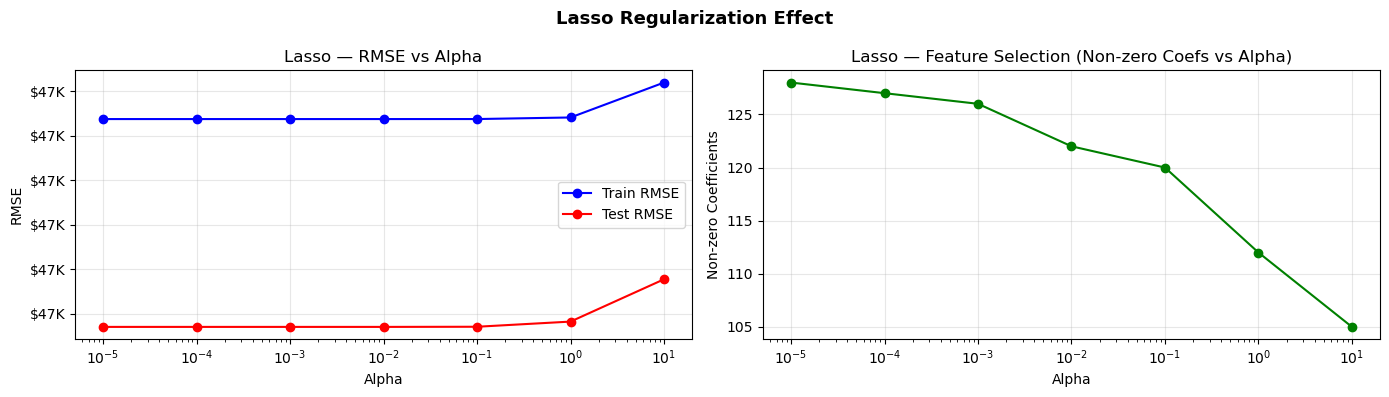

At alpha=0.01: 122 features retained out of 133


In [7]:
# Lasso coefficient sparsity vs alpha
lasso_alphas = [0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10]
lasso_train_rmse, lasso_test_rmse, lasso_nonzero = [], [], []

for a in lasso_alphas:
    m = Lasso(alpha=a, max_iter=10000)
    m.fit(X_train_A, y_train)
    lasso_train_rmse.append(root_mean_squared_error(y_train, m.predict(X_train_A)))
    lasso_test_rmse.append(root_mean_squared_error(y_test,   m.predict(X_test_A)))
    lasso_nonzero.append(np.sum(np.abs(m.coef_) > 1e-6))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].semilogx(lasso_alphas, lasso_train_rmse, 'b-o', label='Train RMSE')
axes[0].semilogx(lasso_alphas, lasso_test_rmse,  'r-o', label='Test RMSE')
axes[0].set_xlabel('Alpha')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Lasso — RMSE vs Alpha')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].semilogx(lasso_alphas, lasso_nonzero, 'g-o')
axes[1].set_xlabel('Alpha')
axes[1].set_ylabel('Non-zero Coefficients')
axes[1].set_title('Lasso — Feature Selection (Non-zero Coefs vs Alpha)')
axes[1].grid(alpha=0.3)

plt.suptitle('Lasso Regularization Effect', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'At alpha=0.01: {lasso_nonzero[3]} features retained out of {len(feature_names_A)}')

---
## Step 4.6 — Model 6: Elastic Net

Elastic Net blends L1 (Lasso) and L2 (Ridge) via `l1_ratio`.  
- `l1_ratio=1.0` → pure Lasso  
- `l1_ratio=0.0` → pure Ridge  
- `l1_ratio=0.5` → balanced hybrid

In [8]:
en_result, en_model, en_pred = evaluate_model(
    'Elastic Net (alpha=0.01, l1=0.5)',
    ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000),
    X_train_A, X_test_A, y_train, y_test
)

[Elastic Net (alpha=0.01, l1=0.5)]  MAE=$36,574  RMSE=$48,967  R²=0.8824  CV_RMSE=$49,212±388


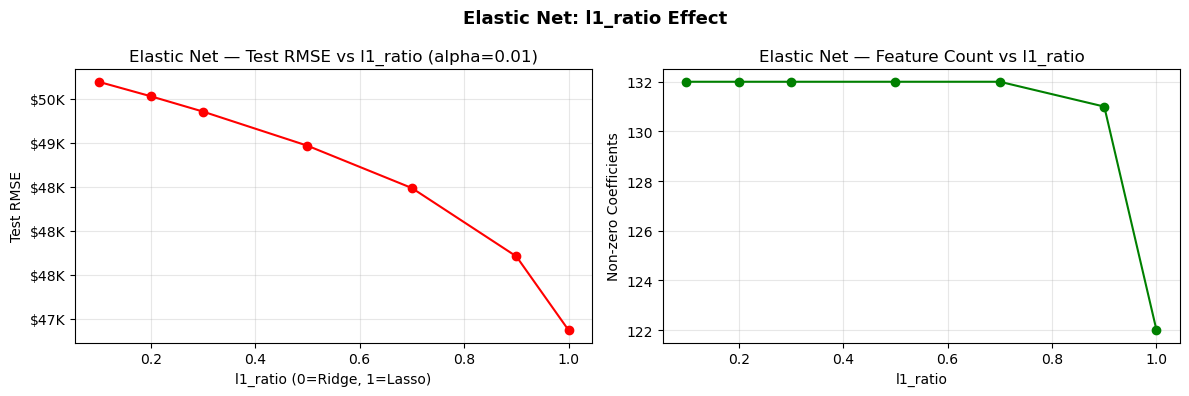

In [9]:
# Elastic Net — l1_ratio effect at fixed alpha=0.01
l1_ratios = [0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 1.0]
en_rmse_test, en_nonzero = [], []

for r in l1_ratios:
    m = ElasticNet(alpha=0.01, l1_ratio=r, max_iter=10000)
    m.fit(X_train_A, y_train)
    en_rmse_test.append(root_mean_squared_error(y_test, m.predict(X_test_A)))
    en_nonzero.append(np.sum(np.abs(m.coef_) > 1e-6))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(l1_ratios, en_rmse_test, 'r-o')
axes[0].set_xlabel('l1_ratio (0=Ridge, 1=Lasso)')
axes[0].set_ylabel('Test RMSE')
axes[0].set_title('Elastic Net — Test RMSE vs l1_ratio (alpha=0.01)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
axes[0].grid(alpha=0.3)

axes[1].plot(l1_ratios, en_nonzero, 'g-o')
axes[1].set_xlabel('l1_ratio')
axes[1].set_ylabel('Non-zero Coefficients')
axes[1].set_title('Elastic Net — Feature Count vs l1_ratio')
axes[1].grid(alpha=0.3)

plt.suptitle('Elastic Net: l1_ratio Effect', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 4.7 — Model 7: Gradient Boosting Regressor (Default)

**Uses Pipeline B** (no scaling)  
**Why GBR is an ensemble**:
- Fits tree 1 → computes residuals → fits tree 2 on residuals → repeat
- Each tree is a "weak learner" (shallow, high bias)
- The sequence of trees collectively reduces both bias and variance
- Learning rate scales each tree's contribution (smaller = more trees needed = better generalization)

**Expected**: Best performing model in this segment, especially after tuning.

In [10]:
# Default GBR — n_estimators=100, learning_rate=0.1, max_depth=3
gbr_result, gbr_model, gbr_pred = evaluate_model(
    'Gradient Boosting (default)',
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3,
                              random_state=42, verbose=0),
    X_train_B, X_test_B, y_train, y_test
)

[Gradient Boosting (default)]  MAE=$29,028  RMSE=$40,049  R²=0.9213  CV_RMSE=$40,412±643


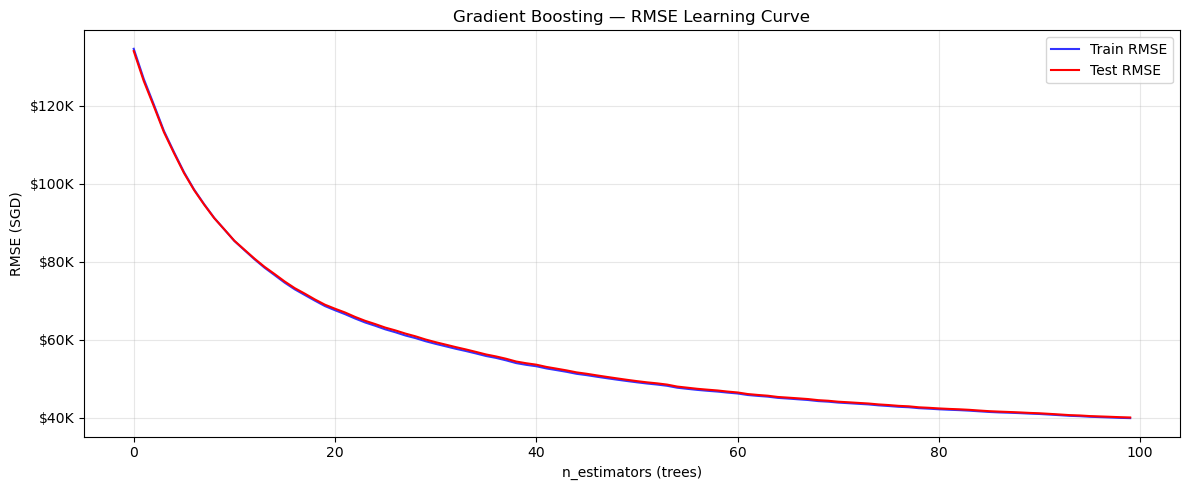

Best n_estimators on test RMSE: 100  (RMSE=$40,049)


In [11]:
# GBR — learning curve (RMSE vs n_estimators)
train_errors = []
test_errors  = []

for pred_train, pred_test in zip(
    gbr_model.staged_predict(X_train_B),
    gbr_model.staged_predict(X_test_B)
):
    train_errors.append(root_mean_squared_error(y_train, pred_train))
    test_errors.append(root_mean_squared_error(y_test,   pred_test))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_errors, 'b-', linewidth=1.5, label='Train RMSE', alpha=0.8)
ax.plot(test_errors,  'r-', linewidth=1.5, label='Test RMSE')
ax.set_xlabel('n_estimators (trees)')
ax.set_ylabel('RMSE (SGD)')
ax.set_title('Gradient Boosting — RMSE Learning Curve', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_n = np.argmin(test_errors) + 1
print(f'Best n_estimators on test RMSE: {best_n}  (RMSE=${min(test_errors):,.0f})')

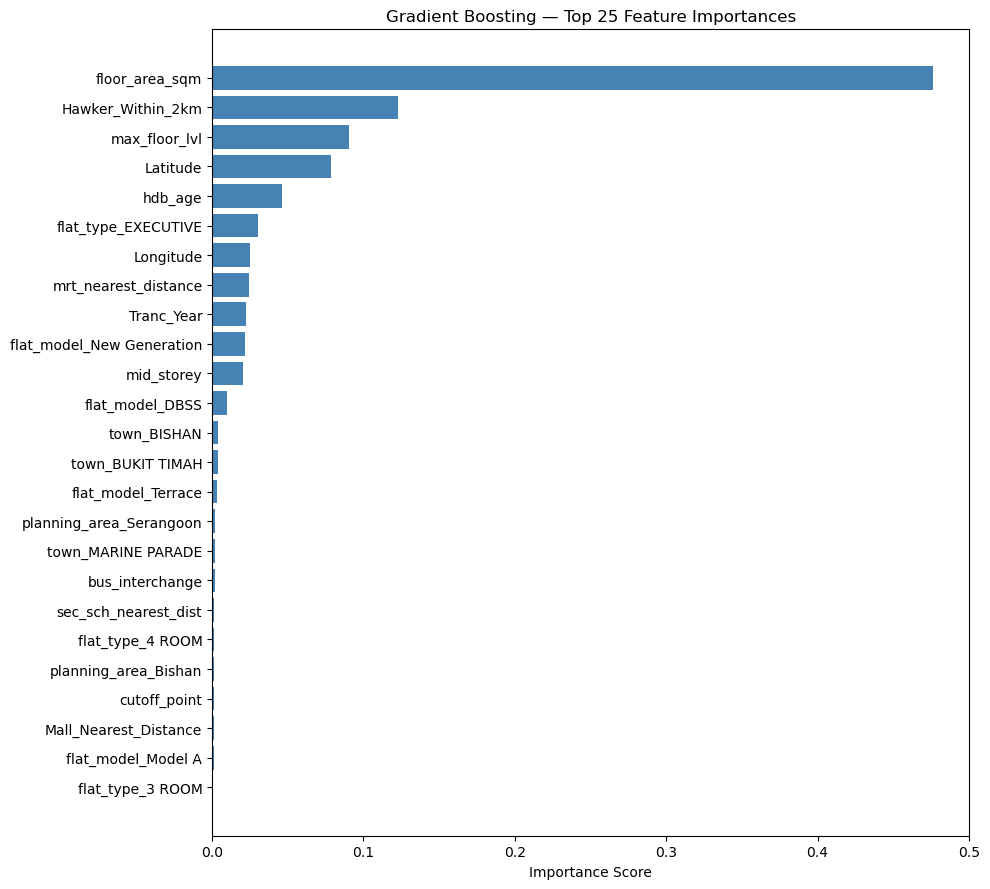

In [12]:
# GBR Feature importance
gbr_importance = pd.DataFrame({
    'Feature'   : feature_names_B,
    'Importance': gbr_model.feature_importances_
}).sort_values('Importance', ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(gbr_importance['Feature'][::-1], gbr_importance['Importance'][::-1], color='steelblue')
ax.set_title('Gradient Boosting — Top 25 Feature Importances', fontsize=12)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

---
## Step 4.8 — Combined Results Table (Segment 3 + Segment 4)

In [13]:
seg4_results = pd.DataFrame([ridge_result, lasso_result, en_result, gbr_result])
all_results  = pd.concat([baseline_results, seg4_results], ignore_index=True)

display_cols = ['Model','Train R²','Test MAE','Test RMSE','Test R²','CV RMSE Mean','R² Gap']
disp = all_results[display_cols].copy()
disp['Test MAE']     = disp['Test MAE'].apply(lambda x: f'${float(x):,.0f}')
disp['Test RMSE']    = disp['Test RMSE'].apply(lambda x: f'${float(x):,.0f}')
disp['CV RMSE Mean'] = disp['CV RMSE Mean'].apply(lambda x: f'${float(x):,.0f}')

print('=== ALL MODELS COMPARISON (Segments 3 + 4) ===')
print(disp.to_string(index=False))

=== ALL MODELS COMPARISON (Segments 3 + 4) ===
                           Model  Train R² Test MAE Test RMSE  Test R²     CV RMSE Mean  R² Gap
               Linear Regression    0.8911  $35,628   $46,870   0.8923 $365,657,800,985     NaN
             KNN Regressor (k=5)    0.9618  $24,549   $34,697   0.9410          $36,785     NaN
 Decision Tree (unlimited depth)    0.9999  $23,856   $33,735   0.9442          $34,717     NaN
               Ridge (alpha=1.0)    0.8911  $35,637   $46,877   0.8922          $47,400 -0.0012
              Lasso (alpha=0.01)    0.8911  $35,629   $46,870   0.8923          $47,398 -0.0012
Elastic Net (alpha=0.01, l1=0.5)    0.8825  $36,574   $48,967   0.8824          $49,212  0.0001
     Gradient Boosting (default)    0.9227  $29,028   $40,049   0.9213          $40,412  0.0013


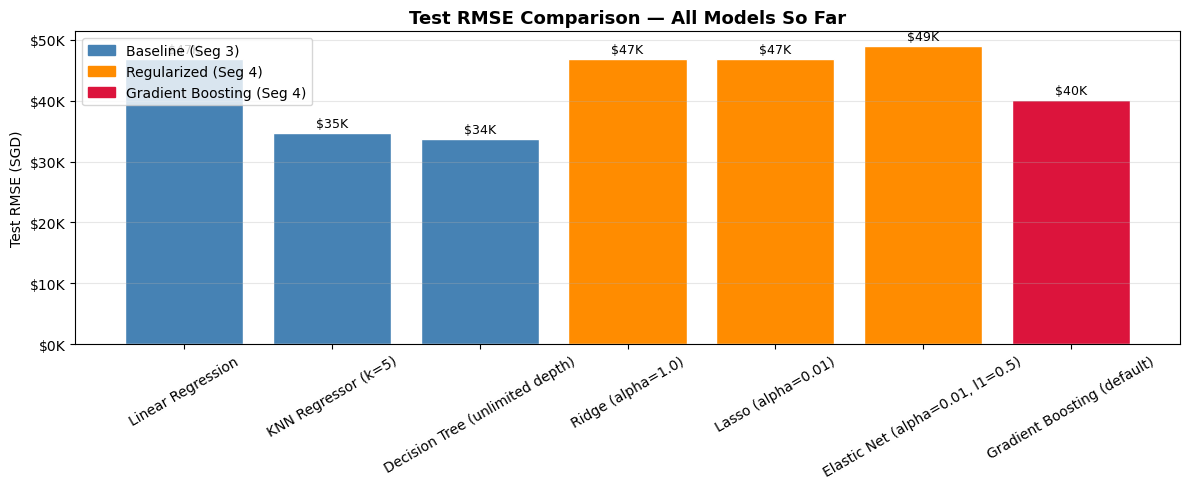

In [14]:
# Bar chart comparison — Test RMSE
rmse_vals = [float(r['Test RMSE']) for _, r in all_results.iterrows()]
model_names = all_results['Model'].tolist()

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['steelblue'] * 3 + ['darkorange'] * 3 + ['crimson']
bars = ax.bar(model_names, rmse_vals, color=colors, edgecolor='white')

for bar, val in zip(bars, rmse_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'${val/1e3:.0f}K', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Test RMSE (SGD)')
ax.set_title('Test RMSE Comparison — All Models So Far', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [Patch(color='steelblue', label='Baseline (Seg 3)'),
                   Patch(color='darkorange', label='Regularized (Seg 4)'),
                   Patch(color='crimson',    label='Gradient Boosting (Seg 4)')]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

---
## Step 4.9 — Save Results and Models

In [15]:
joblib.dump(ridge_model, 'artifacts/model_ridge.pkl')
joblib.dump(lasso_model, 'artifacts/model_lasso.pkl')
joblib.dump(en_model,    'artifacts/model_elasticnet.pkl')
joblib.dump(gbr_model,   'artifacts/model_gbr_default.pkl')

all_results.to_csv('artifacts/results_seg3_seg4.csv', index=False)
seg4_results.to_csv('artifacts/results_regularized_gbr.csv', index=False)

print('Saved: model_ridge.pkl, model_lasso.pkl, model_elasticnet.pkl, model_gbr_default.pkl')
print('Saved: results_regularized_gbr.csv, results_seg3_seg4.csv')

Saved: model_ridge.pkl, model_lasso.pkl, model_elasticnet.pkl, model_gbr_default.pkl
Saved: results_regularized_gbr.csv, results_seg3_seg4.csv


---
## ✅ Segment 4 Complete

**Summary**:
- Ridge reduces multicollinearity issues; stable coefficients
- Lasso performs built-in feature selection; non-zero count tells you effective features
- Elastic Net balances both; best when neither L1 nor L2 alone is optimal
- Gradient Boosting is expected to be the strongest model so far

**Next**: Proceed to `05_hyperparameter_tuning.ipynb`
- GridSearchCV for KNN, Ridge, Lasso, Elastic Net
- RandomizedSearchCV for Decision Tree, Gradient Boosting (large search space)
- Best parameters → retrain → final pre-ensemble comparison